In [17]:
import xarray as xr
import numpy as np
import plotly.graph_objects as go

file_path = "dAtA/cmems_GEBCO_resampled1.nc"

try:
    ds_combined = xr.open_dataset(file_path)
except FileNotFoundError:
    print(f"Error: The file was not found at '{file_path}'")
    print("Please make sure the file path is correct.")
    exit()


lat = ds_combined['latitude'].values
lon = ds_combined['longitude'].values
depth = ds_combined['deptho'].values


lon_grid, lat_grid = np.meshgrid(lon, lat)

# if 'mask' in ds_combined:
#     mask = ds_combined['mask'].values
#     # Ensure mask has the same dimensions as depth before applying
#     if mask.shape == depth.shape:
#         depth = np.where(mask == 1, depth, np.nan)
#     else:
#         print("Warning: Mask shape does not match depth shape. Mask will not be applied.")

surface_trace = go.Surface(
    x=lon_grid,
    y=lat_grid,
    z=-depth,
    colorscale='inferno',
    connectgaps=False,  # Important for handling the land mask (NaNs)
    colorbar=dict(
        title='Depth (m)',
        len=0.75,
        x=0.85
    )
)
fig = go.Figure(data=[surface_trace])
fig.update_layout(
    height=800,
    width=1600,
    title={
        'text': 'Combined Depth',
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth (m)',
        # Set aspect ratio to make the plot look more natural
        aspectratio=dict(x=1.5, y=1.5, z=0.4)
    ),
    margin=dict(l=40, r=40, b=40, t=80) # Adjust margins
)

fig.show()

In [2]:
from netCDF4 import Dataset
all_ds = Dataset(r'dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc')
ds3 = Dataset(r'dAtA/cmems_mod_ibi_wav_my-aflux_0.027deg_P1H-i_TLA-TAUX-TAUY_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc')
ds3.variables.keys()

dict_keys(['TLA', 'TAUX', 'TAUY', 'latitude', 'longitude', 'time'])

In [3]:
import numpy as np

variable_data = all_ds.variables['VMXL'][:]  # Load the data as a NumPy array

# Find the maximum value
max_value = np.max(variable_data)

# Find the index (multi-dimensional) of the maximum value
max_index = np.unravel_index(np.argmax(variable_data), variable_data.shape)
print("Max wave height",max_value)
print(max_index)

Max wave height 11.339999746531248
(33694, 71, 0)


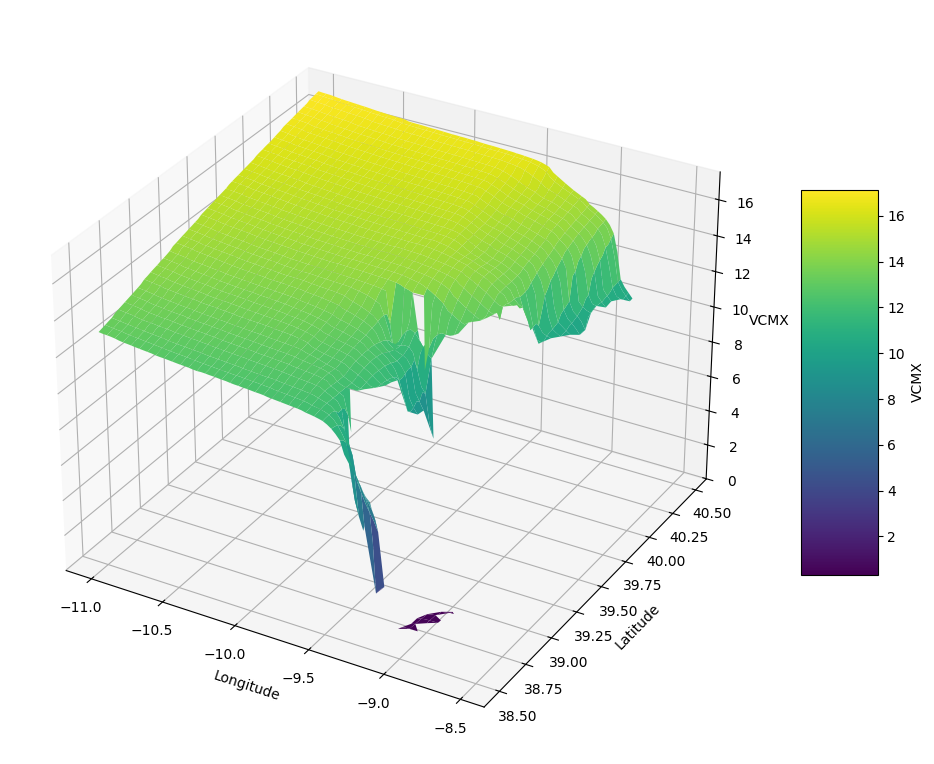

In [6]:
from mpl_toolkits.mplot3d import axis3d
import matplotlib.pyplot as plt

lat = all_ds.variables['latitude'][:]
lon = all_ds.variables['longitude'][:]
vcmx = all_ds.variables['VCMX'][:]

Lat, Lon = np.meshgrid(lon,lat)
Lat.shape

fig = plt.figure(figsize=(12,10))
ax=fig.add_subplot(111, projection='3d')

# ax.view_init(roll=0, azim=0)

# lat = all_ds.variables['latitude'][:]
# lon = all_ds.variables['longitude'][:]
# vcmx = all_ds.variables['VCMX'][:]

# Lat, Lon = np.meshgrid(lat,lon)

surf = ax.plot_surface(Lat ,Lon,vcmx[33694,:,:],cmap='viridis',  edgecolor='none')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('VCMX')
fig.colorbar(surf, shrink=0.5, aspect=5, label='VCMX')

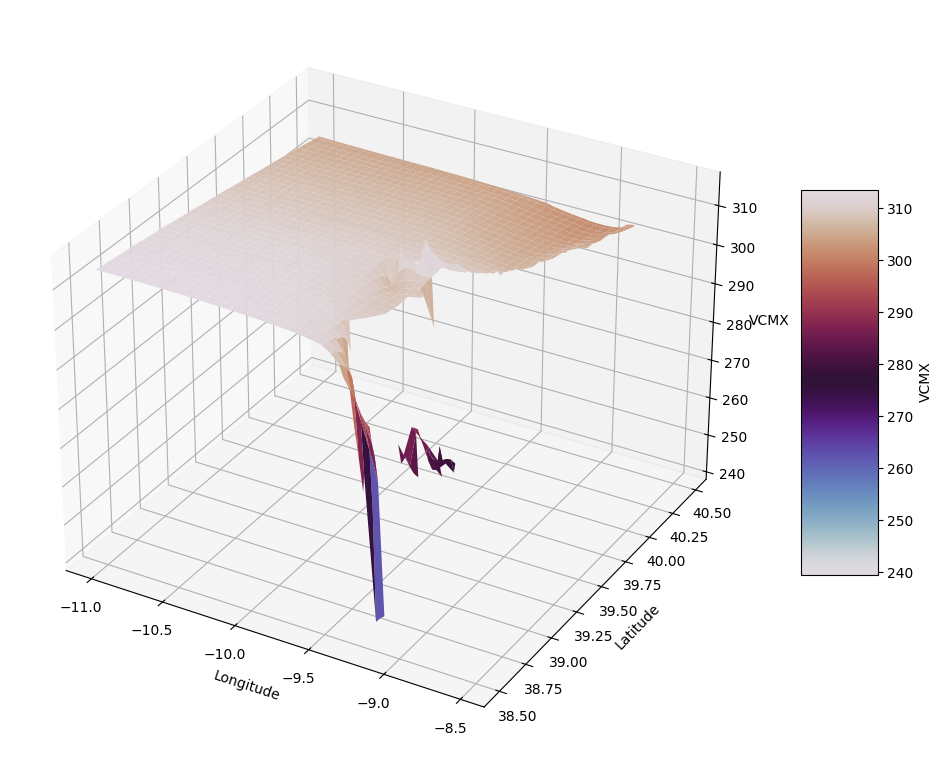

In [9]:
vmdr = all_ds.variables['VMDR'][:]
Lat, Lon = np.meshgrid(lon,lat)
Lat.shape

fig = plt.figure(figsize=(12,10))
ax=fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    Lat, Lon, vmdr[33694,:,:] % 360,
    cmap='twilight',  # cyclic colormap
    edgecolor='none'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('VCMX')
fig.colorbar(surf, shrink=0.5, aspect=5, label='VCMX')

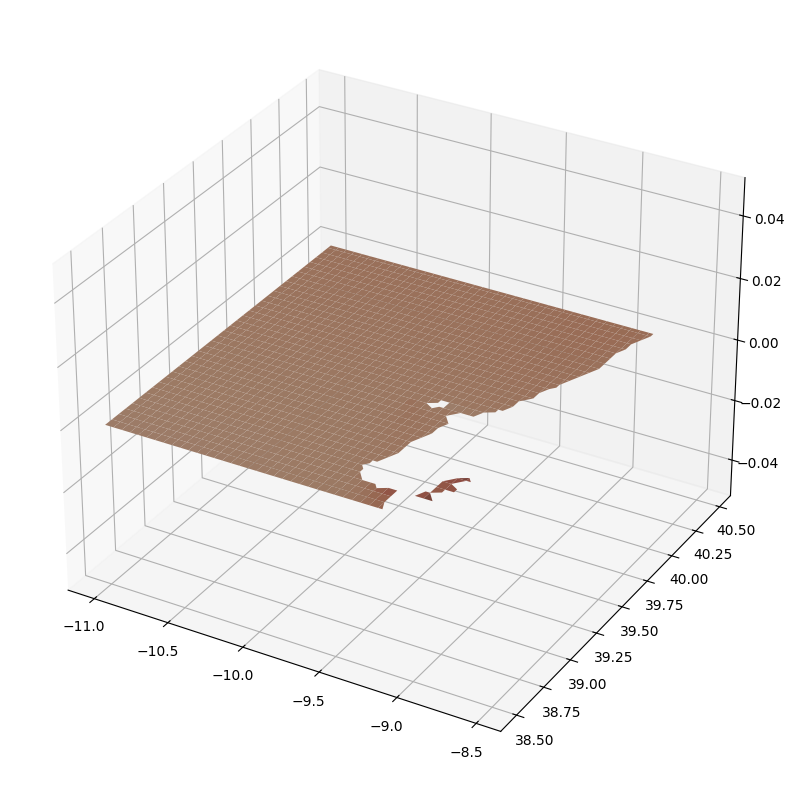

In [12]:
import numpy as np

# Convert degrees to radians
theta = np.deg2rad(vmdr[33694,:,:])

# Direction → vector components
u = np.cos(theta)
v = np.sin(theta)
Lat, Lon = np.meshgrid(lon,lat)
Lat.shape

fig = plt.figure(figsize=(12,10))
ax=fig.add_subplot(111, projection='3d')
Z = np.zeros_like(vmdr[33694,:,:])

surf = ax.plot_surface(
    Lat, Lon, Z,
    facecolors=plt.cm.twilight(vmdr[33694,:,:] / 360),
    edgecolor='none'
)


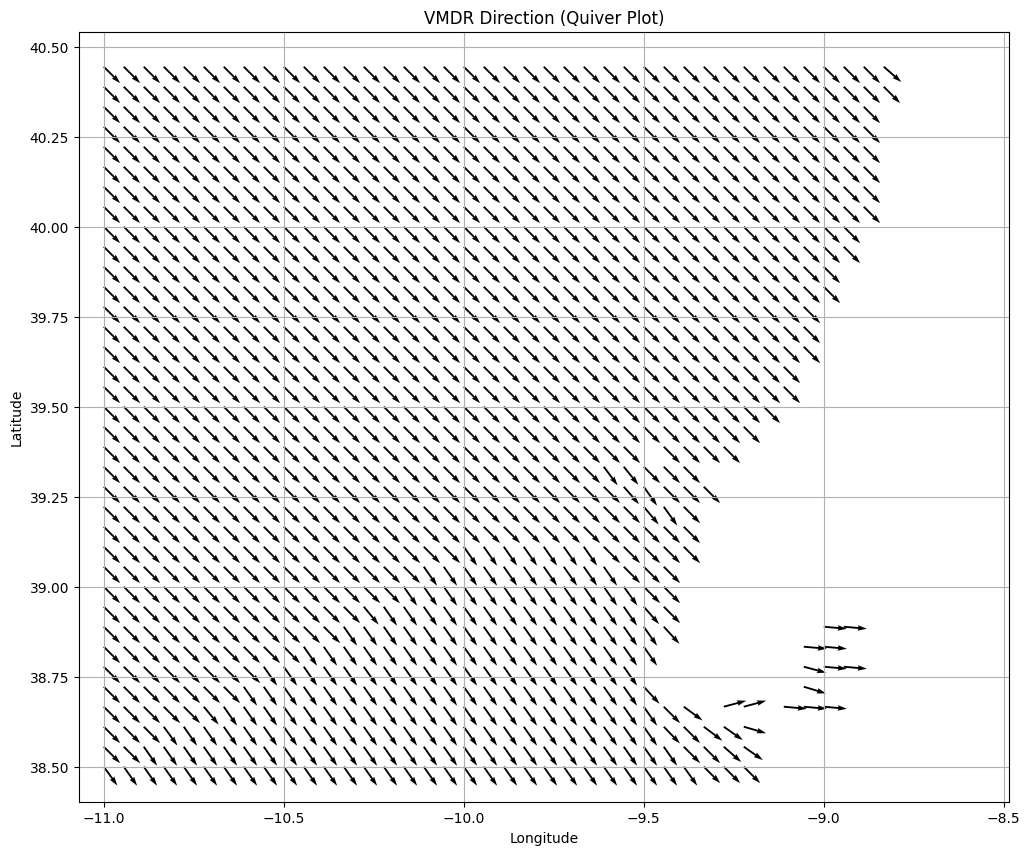

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Select time index
# -------------------------------
t = 33694
vped = all_ds.variables['VPED'][:]

vp_dir = vped[t, :, :]   # direction in degrees
vm_dir = vmdr[t, :, :]   # direction in degrees

# -------------------------------
# Create lat/lon mesh
# -------------------------------
Lon, Lat = np.meshgrid(lon, lat)

# -------------------------------
# Convert direction → vector components
# Direction FROM north, clockwise
# -------------------------------
theta = np.deg2rad(vp_dir)

u = -np.sin(theta)   # x-component (longitude)
v = -np.cos(theta)   # y-component (latitude)

# -------------------------------
# Reduce arrow density
# -------------------------------
skip = 2

# -------------------------------
# Plot quiver
# -------------------------------
plt.figure(figsize=(12, 10))

plt.quiver(
    Lon[::skip, ::skip],
    Lat[::skip, ::skip],
    u[::skip, ::skip],
    v[::skip, ::skip],
    scale=40,
    width=0.002,
    headwidth=3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("VMDR Direction (Quiver Plot)")

plt.axis("equal")
plt.grid(True)
plt.show()


In [3]:
!pip install netCDF4


  Using cached netcdf4-1.7.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached cftime-1.6.5-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (8.7 kB)
Using cached netcdf4-1.7.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (10.4 MB)
Using cached cftime-1.6.5-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [netCDF4]m1/2 [netCDF4]


In [27]:
import numpy as np
import plotly.graph_objects as go
from netCDF4 import Dataset

# -------------------------------------------------
# Load datasets (netCDF4)
# -------------------------------------------------
all_ds = Dataset(
    r'dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
)

ds3 = Dataset(
    r'dAtA/cmems_mod_ibi_wav_my-aflux_0.027deg_P1H-i_TLA-TAUX-TAUY_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
)

ds_bathy = Dataset(
    r'dAtA/cmems_GEBCO_resampled1.nc'
)
ds_mask  = xr.open_dataset(
    "dAtA/cmems_mod_ibi_wav_my_0.027deg_static_1756186965833.nc"
)
# -------------------------------------------------
# Select timestep
# -------------------------------------------------
t = 33694
tn = 33693

# -------------------------------------------------
# Bathymetry
# -------------------------------------------------
lat_b = ds_bathy.variables['latitude'][:]
lon_b = ds_bathy.variables['longitude'][:]
depth = ds_bathy.variables['deptho'][:]

lon_b_grid, lat_b_grid = np.meshgrid(lon_b, lat_b)

# -------------------------------------------------
# Model grid
# -------------------------------------------------
lat = all_ds.variables['latitude'][:]
lon = all_ds.variables['longitude'][:]

lon_grid, lat_grid = np.meshgrid(lon, lat)

# -------------------------------------------------
# Extract variables (NO .values)
# -------------------------------------------------
vcmx = all_ds.variables['VCMX'][t, :, :]
tla  = ds3.variables['TLA'][tn, :, :].data

mask = ds_mask['mask'].values   # <-- if error, print(ds_mask)

# Convert masked arrays → NaN (important for Plotly)
vcmx = np.where(mask == 1, vcmx, np.nan)
tla  = np.where(mask == 1, tla, np.nan)

# -------------------------------------------------
# Vertical offsets
# -------------------------------------------------
z_offset_vcmx = np.nanmax(depth) * 0.02
z_offset_tla  = np.nanmax(depth) * 0.05

# -------------------------------------------------
# Bathymetry surface
# -------------------------------------------------
bathy_surface = go.Surface(
    x=lon_b_grid,
    y=lat_b_grid,
    z=-depth,
    colorscale='Inferno',
    showscale=True,
    colorbar=dict(title='Depth (m)', x=0.80),
    name='Bathymetry'
)

# -------------------------------------------------
# VCMX surface
# -------------------------------------------------
vcmx_surface = go.Surface(
    x=lon_grid,
    y=lat_grid,
    z=vcmx + z_offset_vcmx,
    surfacecolor=vcmx,
    colorscale='Viridis',
    opacity=0.85,
    showscale=True,
    connectgaps=False,
    colorbar=dict(title='VCMX', x=0.88),
    name='VCMX'
)

# -------------------------------------------------
# TLA surface
# -------------------------------------------------
tla_surface = go.Surface(
    x=lon_grid,
    y=lat_grid,
    z=tla + z_offset_tla ,
    surfacecolor=tla,
    colorscale='turbid',
    opacity=0.85,
    showscale=True,
    connectgaps=False,
    colorbar=dict(title='TLA', x=0.96),
    name='TLA'
)

# -------------------------------------------------
# Create figure
# -------------------------------------------------
fig = go.Figure(
    data=[
        bathy_surface,
        vcmx_surface,
        tla_surface
    ]
)

fig.update_layout(
    title=dict(
        text='3D Bathymetry with VCMX and TLA',
        x=0.5
    ),
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth / Variable Value',
        aspectratio=dict(x=1.5, y=1.5, z=0.4)
    ),
    height=900,
    width=1700,
    margin=dict(l=40, r=40, b=40, t=80)
)

fig.show()


In [29]:
ds_mask.variables.keys()

KeysView(Frozen({'mask': <xarray.Variable (latitude: 72, longitude: 90)> Size: 26kB
array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.]], shape=(72, 90), dtype=float32)
Attributes:
    units:          1
    standard_name:  sea_binary_mask
    long_name:      Land-sea mask: 1 = sea ; 0 = land, 'deptho': <xarray.Variable (latitude: 72, longitude: 90)> Size: 26kB
[6480 values with dtype=float32]
Attributes:
    units:          m
    standard_name:  sea_floor_depth_below_geoid
    long_name:      Bathymetry, 'latitude': <xarray.IndexVariable 'latitude' (latitude: 72)> Size: 288B
array([38.50038 , 38.52816 , 38.55594 , 38.583717, 38.611496, 38.639275,
       38.667053, 38.69483 , 38.72261 , 38.75039 , 38.778168, 38.805946,
       38.833725, 38.861504, 38.889282, 38.91706 , 38.94484 , 38.97262 ,
       39.00

In [17]:
import numpy as np
import plotly.graph_objects as go
from netCDF4 import Dataset

# -------------------------------------------------
# Load dataset
# -------------------------------------------------
ds3 = Dataset(
    r'dAtA/cmems_mod_ibi_wav_my-aflux_0.027deg_P1H-i_TLA-TAUX-TAUY_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
)

# -------------------------------------------------
# Select timestep
# -------------------------------------------------
t = 33694

# -------------------------------------------------
# Extract grid
# -------------------------------------------------
lat = ds3.variables['latitude'][:]
lon = ds3.variables['longitude'][:]

# -------------------------------------------------
# Extract TLA
# -------------------------------------------------
tla = ds3.variables['TLA'][t, :, :].data
tla = np.ma.filled(tla, np.nan)  # convert masked → NaN

# -------------------------------------------------
# Plot (2D heatmap)
# -------------------------------------------------
fig = go.Figure(
    go.Heatmap(
        x=lon,
        y=lat,
        z=tla,
        colorscale='Plasma',
        colorbar=dict(title='TLA'),
    )
)

fig.update_layout(
    title='TLA (Single Timestep)',
    xaxis_title='Longitude',
    yaxis_title='Latitude',
    height=700,
    width=900
)

fig.show()


In [16]:
tla = ds3.variables['TLA'][t, :, :]
print(tla)

[[-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 ...
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]
 [-- -- -- ... -- -- --]]


In [24]:
import xarray as xr
import numpy as np
import plotly.graph_objects as go

# ---------------------------
# Load datasets
# ---------------------------
ds_bathy = xr.open_dataset("dAtA/cmems_GEBCO_resampled1.nc")
ds_model = all_ds  # already loaded wave/model dataset
ds_mask  = xr.open_dataset(
    "dAtA/cmems_mod_ibi_wav_my_0.027deg_static_1756186965833.nc"
)

# ---------------------------
# Bathymetry
# ---------------------------
lat_b = ds_bathy['latitude'].values
lon_b = ds_bathy['longitude'].values
depth = ds_bathy['deptho'].values

lon_b_grid, lat_b_grid = np.meshgrid(lon_b, lat_b)

# ---------------------------
# VCMX (single timestep)
# ---------------------------
t = 33694

lat_m = ds_model['latitude'][:]
lon_m = ds_model['longitude'][:]
vcmx = ds_model['VCMX'][t, :, :]

lon_m_grid, lat_m_grid = np.meshgrid(lon_m, lat_m)

# ---------------------------
# Load mask (CHANGE variable name here if needed)
# ---------------------------
mask = ds_mask['mask'].values   # <-- if error, print(ds_mask)

# ---------------------------
# Apply mask to VCMX
# ---------------------------
# Mask land points → NaN
vcmx_masked = np.where(mask == 1, vcmx, np.nan)

# ---------------------------
# Surface 1: Bathymetry
# ---------------------------
bathy_surface = go.Surface(
    x=lon_b_grid,
    y=lat_b_grid,
    z=-depth,
    colorscale='Inferno',
    showscale=True,
    colorbar=dict(
        title='Depth (m)',
        x=0.85
    ),
    name='Bathymetry'
)

# ---------------------------
# Surface 2: Masked VCMX
# ---------------------------
# Vertical offset so it sits above seabed
z_offset = np.nanmax(depth) * 0.02

vcmx_surface = go.Surface(
    x=lon_m_grid,
    y=lat_m_grid,
    z=vcmx_masked + z_offset,
    surfacecolor=vcmx_masked,
    colorscale='Viridis',
    opacity=0.9,
    showscale=True,
    colorbar=dict(
        title='VCMX',
        x=0.95
    ),
    connectgaps=False,  # IMPORTANT for masked NaNs
    name='VCMX (masked)'
)

# ---------------------------
# Create figure
# ---------------------------
fig = go.Figure(data=[bathy_surface, vcmx_surface])

fig.update_layout(
    title=dict(
        text='3D Interactive Bathymetry + Masked VCMX',
        x=0.5
    ),
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth / VCMX',
        aspectratio=dict(x=1.5, y=1.5, z=0.4)
    ),
    height=850,
    width=1600,
    margin=dict(l=40, r=40, b=40, t=80)
)

fig.show()


In [ ]:
import xarray as xr
import numpy as np
import plotly.graph_objects as go

# ---------------------------
# Load datasets
# ---------------------------
ds_bathy = xr.open_dataset("dAtA/cmems_GEBCO_resampled1.nc")
ds_model = all_ds   # your wave model dataset (VCMX, VPED)
ds_mask  = xr.open_dataset("dAtA/cmems_mod_ibi_wav_my_0.027deg_static_1756186965833.nc")

# ---------------------------
# Bathymetry
# ---------------------------
lat_b = ds_bathy['latitude'].values
lon_b = ds_bathy['longitude'].values
depth = ds_bathy['deptho'].values
lon_b_grid, lat_b_grid = np.meshgrid(lon_b, lat_b)

# ---------------------------
# VCMX (single timestep)
# ---------------------------
t = 33694
lat_m = ds_model['latitude'][:]
lon_m = ds_model['longitude'][:]
vcmx = ds_model['VHM0'][t, :, :]

# ---------------------------
# Apply mask
# ---------------------------
mask = ds_mask['mask'].values   # 1=sea, 0=land
vcmx_masked = np.where(mask == 1, vcmx, np.nan)

lon_m_grid, lat_m_grid = np.meshgrid(lon_m, lat_m)

# ---------------------------
# VPED / VMDR vectors
# ---------------------------
vp_dir = ds_model['VPED'][t, :, :]   # degrees
theta = np.deg2rad(vp_dir)
u = -np.sin(theta)
v = -np.cos(theta)
w = np.zeros_like(u)   # horizontal arrows

# Downsample for clarity
skip = 5
Lon_s = lon_m_grid[::skip, ::skip]
Lat_s = lat_m_grid[::skip, ::skip]
u_s = u[::skip, ::skip]
v_s = v[::skip, ::skip]
w_s = w[::skip, ::skip]
z_s = vcmx_masked[::skip, ::skip] + np.nanmax(vcmx_masked)*0.05  # offset above VCMX

# ---------------------------
# Bathymetry surface
# ---------------------------
bathy_surface = go.Surface(
    x=lon_b_grid,
    y=lat_b_grid,
    z=-depth,
    colorscale='Inferno',
    showscale=True,
    colorbar=dict(title='Depth (m)', x=0.85),
    name='Bathymetry'
)

# ---------------------------
# VCMX surface
# ---------------------------
vcmx_surface = go.Surface(
    x=lon_m_grid,
    y=lat_m_grid,
    z=vcmx_masked,
    surfacecolor=vcmx_masked,
    colorscale='Viridis',
    opacity=0.9,
    showscale=True,
    colorbar=dict(title='VCMX', x=0.95),
    connectgaps=False,
    name='VCMX (masked)'
)

# ---------------------------
# VPED vectors as cones
# ---------------------------
cone_trace = go.Cone(
    x=Lon_s.flatten(),
    y=Lat_s.flatten(),
    z=z_s.flatten(),
    u=u_s.flatten(),
    v=v_s.flatten(),
    w=w_s.flatten(),
    colorscale='Blues',
    sizemode='scaled',
    sizeref=0.5,
    anchor='tail',
    showscale=False,
    name='VPED Direction'
)

# ---------------------------
# Combine all in one figure
# ---------------------------
fig = go.Figure(data=[bathy_surface, vcmx_surface, cone_trace])

fig.update_layout(
    title=dict(text='3D Bathymetry + Masked VCMX + VPED Vectors', x=0.5),
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth / VCMX',
        aspectratio=dict(x=1.5, y=1.5, z=0.4)
    ),
    height=850,
    width=1600,
    margin=dict(l=40, r=40, b=40, t=80)
)

fig.show()

In [1]:
plt.savefig('study_area_bathymetry.png', dpi=300, bbox_inches='tight')

NameError: name 'plt' is not defined

In [ ]:
 "VMDR_SW2", "VMDR_WW", "VMXL","VPED", "VSDX", "VSDY", "VTM01_SW1", "VTM01_SW2", "VTM01_WW", "VTM02", "VTM10", "VTPK"

In [ ]:
import copernicusmarine

copernicusmarine.subset(
  dataset_id="cmems_mod_ibi_wav_my_0.027deg_PT1H-i",
  dataset_version="202511",
  variables=["VMDR_SW1", "VCMX", "VHM0", "VHM0_SW1", "VHM0_SW2", "VHM0_WW", "VMDR"],
  minimum_longitude=-13,
  maximum_longitude=-8.5,
  minimum_latitude=39,
  maximum_latitude=43.5,
  start_datetime="2020-01-01T00:00:00",
  end_datetime="2023-12-30T00:00:00",
  coordinates_selection_method="strict-inside",
  file_format="netcdf",          # 👈 IMPORTANT 
  netcdf_compression_level=1,
  disable_progress_bar=False,
)


# copernicusmarine.subset(
#   dataset_id="cmems_mod_ibi_wav_my-aflux_0.027deg_P1H-i",
#   dataset_version="202511",
#   variables=["TAUX", "TAUY", "TLA"],
#   minimum_longitude=-13,
#   maximum_longitude=-8.5,
#   minimum_latitude=39,
#   maximum_latitude=43.5,
#   start_datetime="2020-01-01T00:00:00",
#   end_datetime="2023-12-30T00:00:00",
#   coordinates_selection_method="strict-inside",
#   netcdf_compression_level=1,
#   netcdf3_compatible=False,
#   file_format="zarr",
#   disable_progress_bar=False,
# )


INFO - 2026-01-09T07:03:49Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine username:Copernicus Marine password:

In [ ]:
copernicusmarine subset --dataset-id cmems_mod_ibi_wav_my_0.027deg_PT1H-i --dataset-version 202511 --variable VMDR_SW1 --variable VCMX --variable VHM0 --variable VHM0_SW1 --variable VHM0_SW2 --variable VHM0_WW --variable VMDR --variable VMDR_SW2 --variable VMDR_WW --variable VMXL --variable VPED --variable VSDX --variable VSDY --variable VTM01_SW1 --variable VTM01_SW2 --variable VTM01_WW --variable VTM02 --variable VTM10 --variable VTPK --start-datetime 2020-01-01T12:00:00 --end-datetime 2023-12-30T12:00:00 --minimum-longitude -13 --maximum-longitude -8.5 --minimum-latitude 39 --maximum-latitude 43.5 --coordinates-selection-method strict-inside --netcdf-compression-level 1 --disable-progress-bar --log-level ERROR

copernicusmarine subset --dataset-id cmems_mod_ibi_wav_my-aflux_0.027deg_P1H-i --dataset-version 202511 --variable TAUX --variable TAUY --variable TLA --start-datetime 2020-01-01T12:00:00 --end-datetime 2022-12-30T12:00:00 --minimum-longitude -13 --maximum-longitude -8.5 --minimum-latitude 39 --maximum-latitude 43.5 --coordinates-selection-method strict-inside --netcdf-compression-level 1 --log-level ERROR

In [42]:
import xarray, zarr
print(xarray.__version__)
print(zarr.__version__)


2023.6.0
3.1.5
